# 🏡 California Housing

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [56]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 90
np.random.seed(42)
print("Settings done")

Settings done


In [57]:
df = pd.read_csv("housing.csv")
print("File loaded")

File loaded


In [60]:
print("Rows, Columns:", df.shape)

Rows, Columns: (20640, 10)


In [59]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [61]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [62]:
df.sample(5, random_state=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0,<1H OCEAN
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0,INLAND
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0,NEAR BAY
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0,NEAR BAY
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0,<1H OCEAN


The meaning of each column:

| Column | Meaning |
|---|---|
| `longitude` | east-west location of the block |
| `latitude` | north-south location of the block |
| `housing_median_age` | median age of houses (years) |
| `total_rooms` | total rooms across all houses in the block |
| `total_bedrooms` | total bedrooms in the block |
| `population` | total population of the block |
| `households` | number of households |
| `median_income` | median income (in units of $10,000) |
| `ocean_proximity` | proximity to ocean (categorical) |
| `median_house_value` | 🎯 **TARGET** — the median house value to predict (dollars) |

In [63]:
df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [64]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [67]:
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [68]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [69]:
df["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

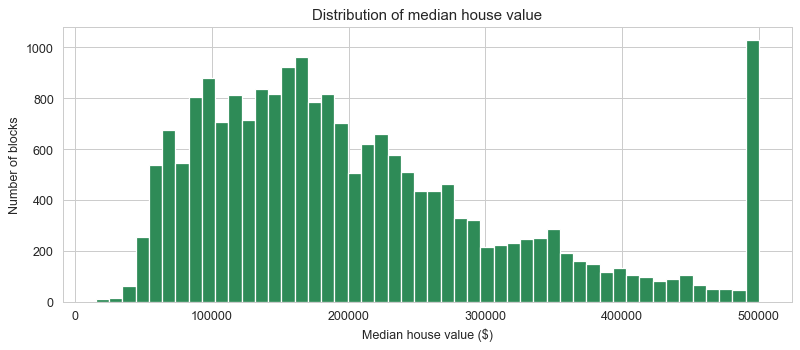

In [70]:
plt.figure(figsize=(9, 4))
df["median_house_value"].hist(bins=50, color="seagreen", edgecolor="white")
plt.xlabel("Median house value ($)")
plt.ylabel("Number of blocks")
plt.title("Distribution of median house value")
plt.tight_layout()
plt.show()

In [71]:
n_capped = (df["median_house_value"] == 500001).sum()
total = len(df)
print(f"Blocks at the $500,001 cap: {n_capped} out of {total} ({n_capped/total*100:.1f}%)")

Blocks at the $500,001 cap: 965 out of 20640 (4.7%)


In [ ]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

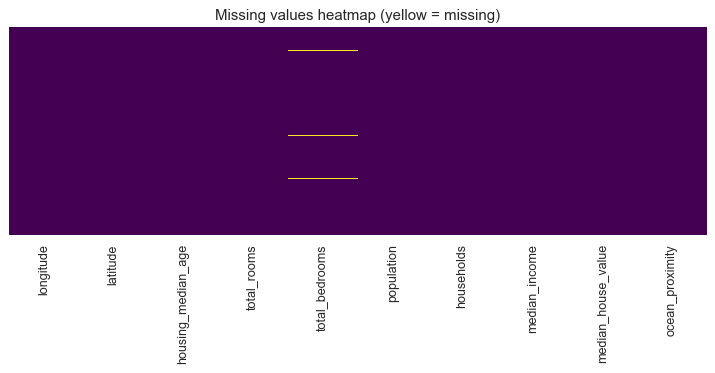

In [73]:
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values heatmap (yellow = missing)")
plt.show()

In [74]:
# Option A: drop those rows
print("Original shape:", df.shape)
print("After dropna() :", df.dropna().shape, "  (we lose 207 rows)")

Original shape: (20640, 10)
After dropna() : (20433, 10)   (we lose 207 rows)


In [75]:
# Option B: fill with mean
mean_bedrooms = df["total_bedrooms"].mean()
print(f"Could fill with mean = {mean_bedrooms:.1f}")

Could fill with mean = 537.9


In [76]:
# Option C: fill with median (safer for skewed data)
median_bedrooms = df["total_bedrooms"].median()
print(f"Will fill with median = {median_bedrooms:.1f}")

Will fill with median = 435.0


In [77]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)
print("Missing values now:", df["total_bedrooms"].isnull().sum())

Missing values now: 0


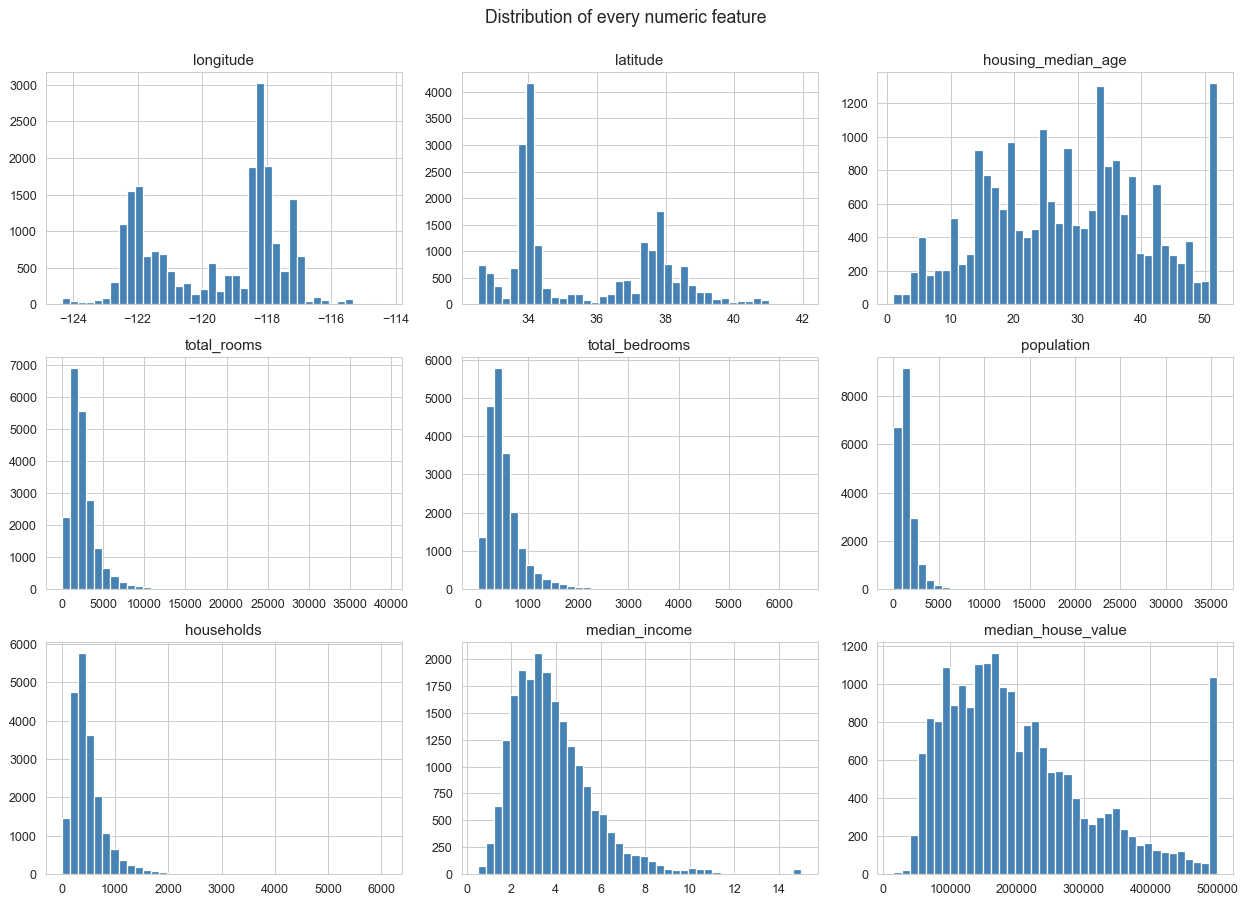

In [78]:
df.hist(bins=40, figsize=(14, 10), color="steelblue", edgecolor="white")
plt.suptitle("Distribution of every numeric feature", y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

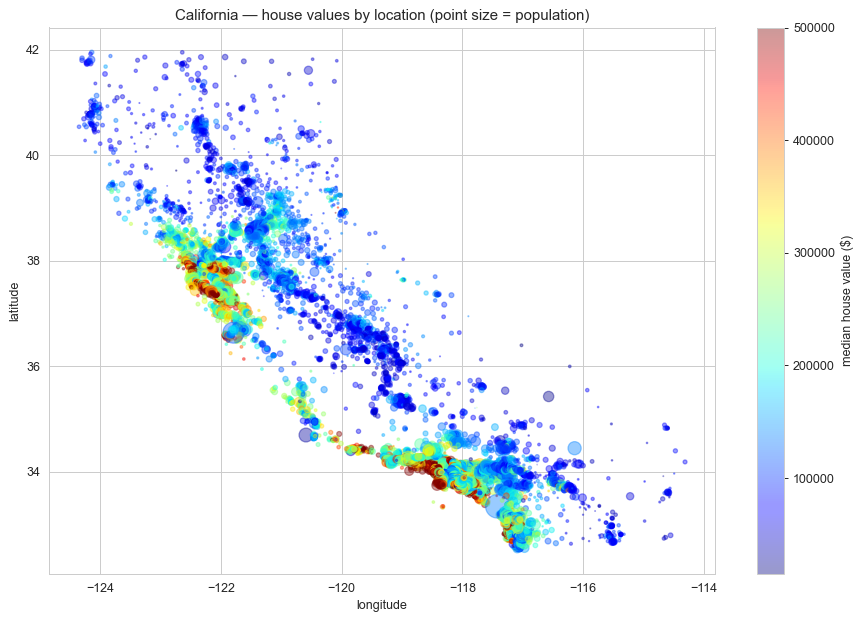

In [79]:
plt.figure(figsize=(10, 7))
plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value"], cmap="jet",
            alpha=0.4, s=df["population"] / 100)
plt.colorbar(label="median house value ($)")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("California — house values by location (point size = population)")
plt.tight_layout()
plt.show()

In [80]:
# Drop the categorical column for correlation
numeric_df = df.drop(columns=["ocean_proximity"])
corr_with_target = numeric_df.corr()["median_house_value"].drop("median_house_value")
corr_with_target.sort_values(ascending=False).round(3)

median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.049
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64

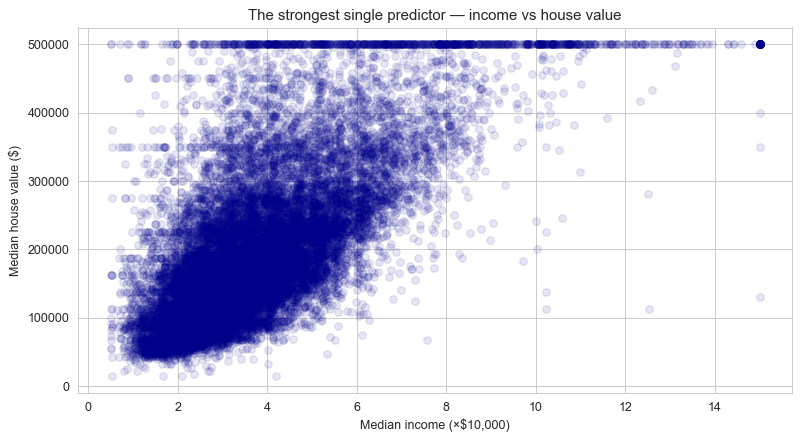

In [81]:
plt.figure(figsize=(9, 5))
plt.scatter(df["median_income"], df["median_house_value"],
            alpha=0.1, color="darkblue")
plt.xlabel("Median income (×$10,000)")
plt.ylabel("Median house value ($)")
plt.title("The strongest single predictor — income vs house value")
plt.tight_layout()
plt.show()

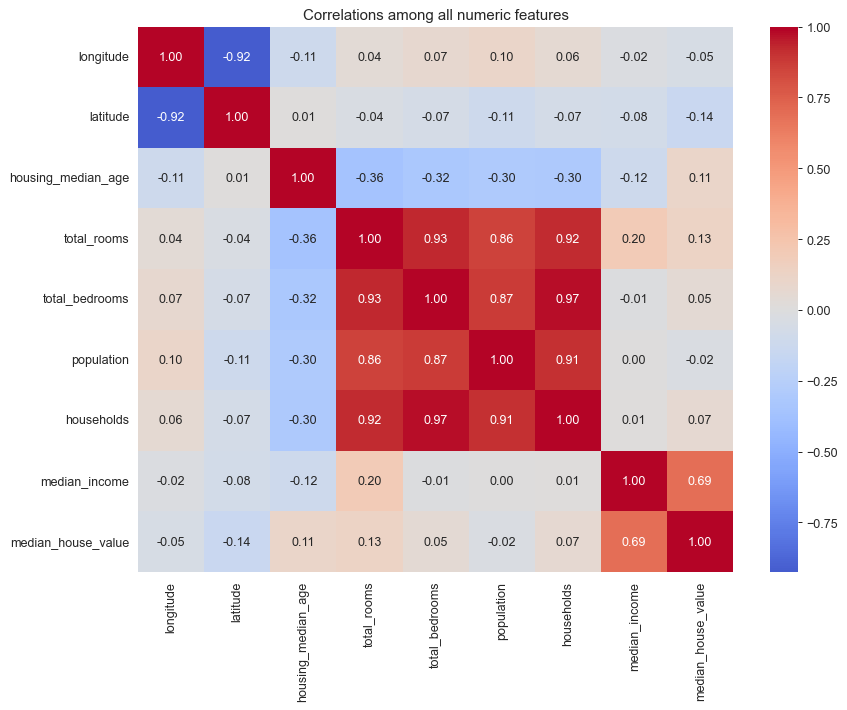

In [82]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0,
            fmt=".2f", annot_kws={"size": 10})
plt.title("Correlations among all numeric features")
plt.tight_layout()
plt.show()

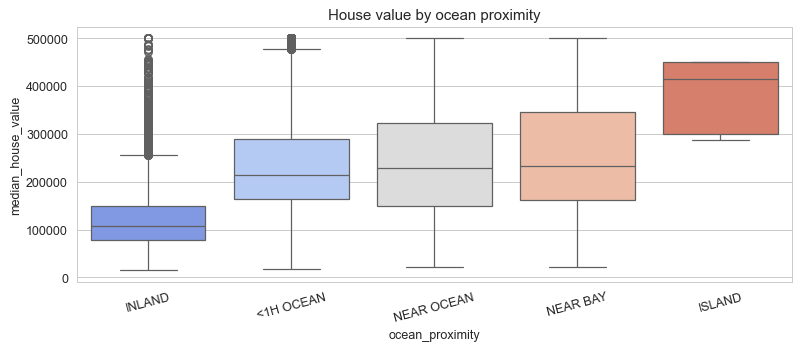

In [83]:
plt.figure(figsize=(9, 4))
order = ["INLAND", "<1H OCEAN", "NEAR OCEAN", "NEAR BAY", "ISLAND"]
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df, order=order,
            palette="coolwarm")
plt.title("House value by ocean proximity")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [28]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["rooms_per_household"].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: rooms_per_household, dtype: float64

In [29]:
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["bedrooms_per_room"].describe()

count    20640.000000
mean         0.213794
std          0.065248
min          0.037151
25%          0.175225
50%          0.203159
75%          0.240126
max          2.824675
Name: bedrooms_per_room, dtype: float64

In [30]:
df["population_per_household"] = df["population"] / df["households"]
df["population_per_household"].describe()

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: population_per_household, dtype: float64

In [31]:
new_corr = df.drop(columns=["ocean_proximity"]).corr()["median_house_value"].drop("median_house_value")
new_corr.sort_values(ascending=False).round(3)

median_income               0.688
rooms_per_household         0.152
total_rooms                 0.134
housing_median_age          0.106
households                  0.066
total_bedrooms              0.049
population_per_household   -0.024
population                 -0.025
longitude                  -0.046
latitude                   -0.144
bedrooms_per_room          -0.233
Name: median_house_value, dtype: float64

In [84]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [85]:
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True, dtype=int)
print("New shape:", df_encoded.shape)
df_encoded.head()

New shape: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [34]:
X = df_encoded.drop(columns=["median_house_value"])
y = df_encoded["median_house_value"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 15)
y shape: (20640,)


In [35]:
print("Final features:")
for col in X.columns:
    print(" -", col)

Final features:
 - longitude
 - latitude
 - housing_median_age
 - total_rooms
 - total_bedrooms
 - population
 - households
 - median_income
 - rooms_per_household
 - bedrooms_per_room
 - population_per_household
 - ocean_proximity_INLAND
 - ocean_proximity_ISLAND
 - ocean_proximity_NEAR BAY
 - ocean_proximity_NEAR OCEAN


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print("Training:", X_train.shape, " ", y_train.shape)
print("Testing: ", X_test.shape,  " ", y_test.shape)

Training: (16512, 15)   (16512,)
Testing:  (4128, 15)   (4128,)


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)         # use train's mean/std on test

print("Scaled — mean ≈ 0, std ≈ 1 on training set")
print(f"  Train mean: {X_train_s.mean():.4f}")
print(f"  Train std:  {X_train_s.std():.4f}")

Scaled — mean ≈ 0, std ≈ 1 on training set
  Train mean: 0.0000
  Train std:  1.0000


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression")
print(f"  RMSE: ${rmse_lr:,.0f}")
print(f"  MAE:  ${mae_lr:,.0f}")
print(f"  R²:   {r2_lr:.4f}")

Linear Regression
  RMSE: $72,669
  MAE:  $50,889
  R²:   0.5970


In [39]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression")
print(f"  RMSE: ${rmse_ridge:,.0f}")
print(f"  MAE:  ${mae_ridge:,.0f}")
print(f"  R²:   {r2_ridge:.4f}")

Ridge Regression
  RMSE: $72,666
  MAE:  $50,888
  R²:   0.5970


In [40]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)         # trees don't need scaling
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print(f"Decision Tree")
print(f"  RMSE: ${rmse_dt:,.0f}")
print(f"  MAE:  ${mae_dt:,.0f}")
print(f"  R²:   {r2_dt:.4f}")

Decision Tree
  RMSE: $63,535
  MAE:  $40,785
  R²:   0.6920


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=None,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest")
print(f"  RMSE: ${rmse_rf:,.0f}")
print(f"  MAE:  ${mae_rf:,.0f}")
print(f"  R²:   {r2_rf:.4f}")

Random Forest
  RMSE: $50,357
  MAE:  $32,328
  R²:   0.8065


In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting")
print(f"  RMSE: ${rmse_gb:,.0f}")
print(f"  MAE:  ${mae_gb:,.0f}")
print(f"  R²:   {r2_gb:.4f}")

Gradient Boosting
  RMSE: $47,727
  MAE:  $31,256
  R²:   0.8262


In [43]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Decision Tree",
              "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_dt, rmse_rf, rmse_gb],
    "MAE":  [mae_lr,  mae_ridge,  mae_dt,  mae_rf,  mae_gb],
    "R²":   [r2_lr,   r2_ridge,   r2_dt,   r2_rf,   r2_gb],
}).sort_values("RMSE").reset_index(drop=True)
results.round(4)

,Model,RMSE,MAE,R²
0,Gradient Boosting,47726.5958,31255.9579,0.8262
1,Random Forest,50356.5965,32328.3704,0.8065
2,Decision Tree,63535.0721,40785.1482,0.6920
3,Ridge,72666.3482,50888.3197,0.5970
4,Linear Regression,72668.5384,50888.6600,0.5970


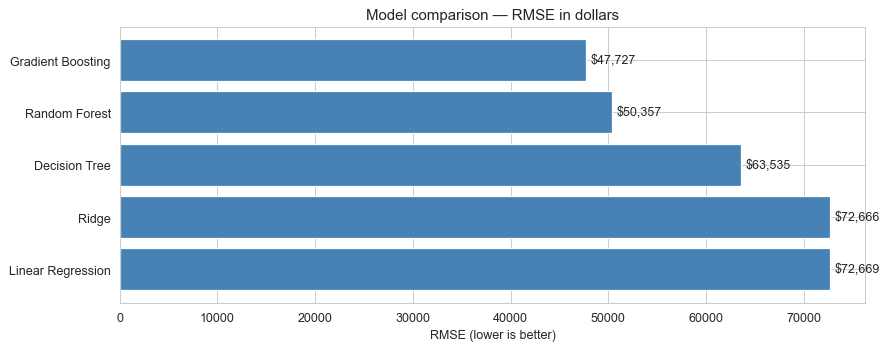

In [44]:
plt.figure(figsize=(10, 4))
bars = plt.barh(results["Model"], results["RMSE"], color="steelblue")
plt.xlabel("RMSE (lower is better)")
plt.title("Model comparison — RMSE in dollars")
for bar, rmse in zip(bars, results["RMSE"]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f"${rmse:,.0f}", va="center", fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [90]:
best_name = results.iloc[0]["Model"]
all_models = {
    "Linear Regression": (lr, y_pred_lr, True),
    "Ridge":             (ridge, y_pred_ridge, True),
    "Decision Tree":     (dt, y_pred_dt, False),
    "Random Forest":     (rf, y_pred_rf, False),
    "Gradient Boosting": (gb, y_pred_gb, False),
}
best_model, best_pred, _ = all_models[best_name]
print(f"Best model: {best_name}")

Best model: Gradient Boosting


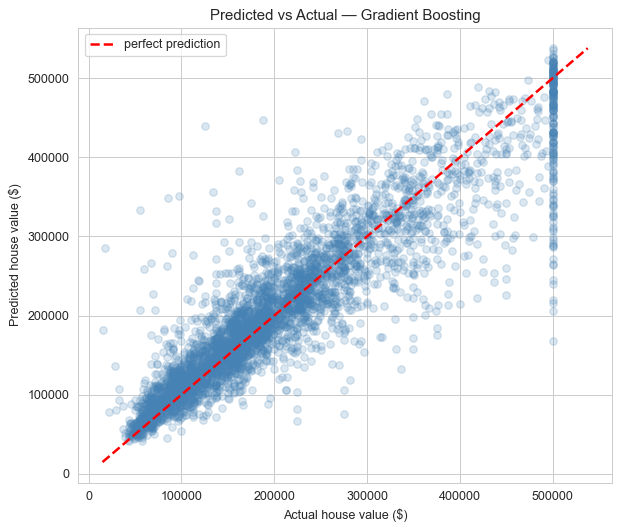

In [46]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.2, color="steelblue")
# perfect prediction line
mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="perfect prediction")
plt.xlabel("Actual house value ($)")
plt.ylabel("Predicted house value ($)")
plt.title(f"Predicted vs Actual — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

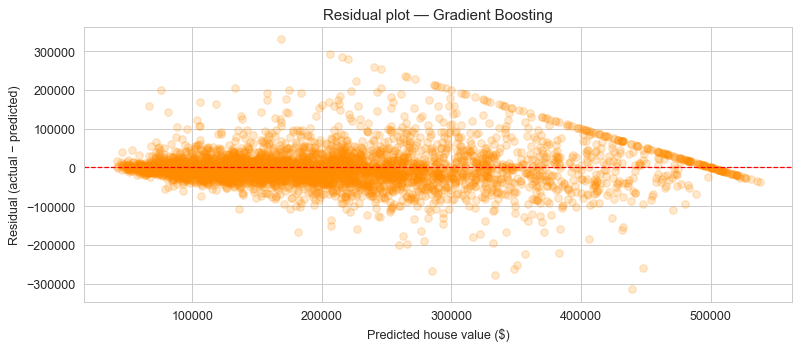

In [47]:
residuals = y_test - best_pred

plt.figure(figsize=(9, 4))
plt.scatter(best_pred, residuals, alpha=0.2, color="darkorange")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted house value ($)")
plt.ylabel("Residual (actual − predicted)")
plt.title(f"Residual plot — {best_name}")
plt.tight_layout()
plt.show()

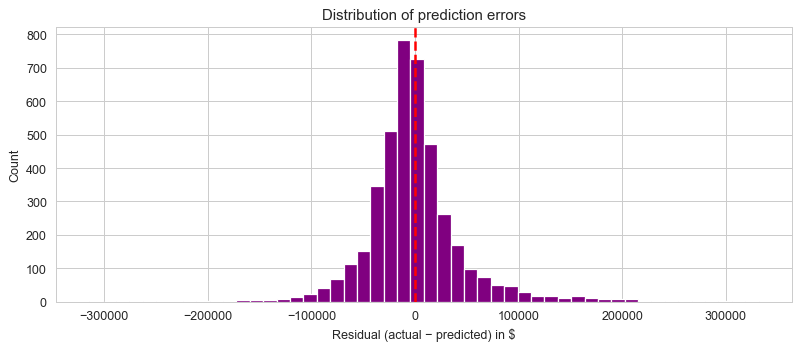

Mean residual:   $-1,349  (should be close to 0)
Median residual: $-4,675
Std of errors:   $47,713


In [48]:
plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=50, color="purple", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Residual (actual − predicted) in $")
plt.ylabel("Count")
plt.title("Distribution of prediction errors")
plt.tight_layout()
plt.show()

print(f"Mean residual:   ${residuals.mean():,.0f}  (should be close to 0)")
print(f"Median residual: ${residuals.median():,.0f}")
print(f"Std of errors:   ${residuals.std():,.0f}")

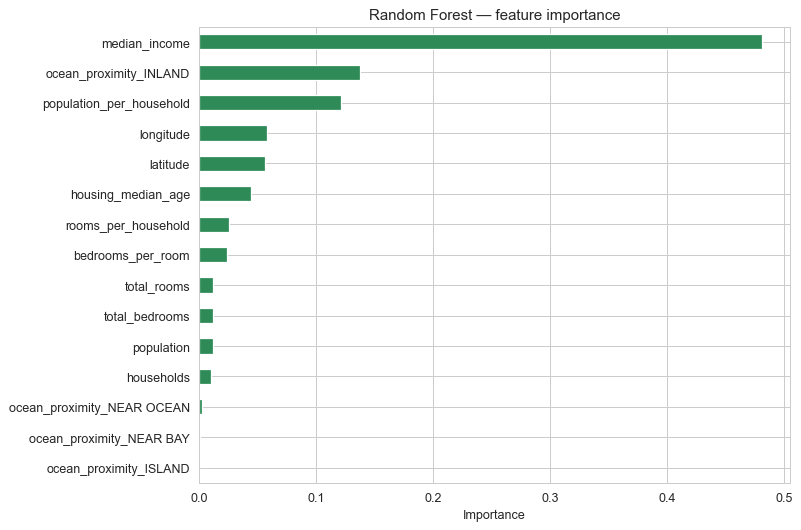

In [49]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="seagreen")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [50]:
print("Top 5 most important features:")
importances.tail(5).iloc[::-1]

Top 5 most important features:


median_income               0.481661
ocean_proximity_INLAND      0.137520
population_per_household    0.121586
longitude                   0.057939
latitude                    0.056532
dtype: float64

In [87]:
from sklearn.model_selection import cross_val_score

# Negative MSE because sklearn maximizes scores — we negate to get positive RMSE
cv_scores = cross_val_score(rf, X, y, cv=5,
                            scoring="neg_root_mean_squared_error",
                            n_jobs=-1)
cv_rmse = -cv_scores

print("5-fold CV RMSE for Random Forest:")
for i, score in enumerate(cv_rmse):
    print(f"  Fold {i+1}: ${score:,.0f}")
print(f"\nMean RMSE: ${cv_rmse.mean():,.0f}")
print(f"Std:       ${cv_rmse.std():,.0f}")

5-fold CV RMSE for Random Forest:
  Fold 1: $76,909
  Fold 2: $63,976
  Fold 3: $61,108
  Fold 4: $83,152
  Fold 5: $62,364

Mean RMSE: $69,502
Std:       $8,867


In [52]:
from sklearn.model_selection import GridSearchCV

# Smaller grid because RF is slow on 20k rows
param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [10, None],
    "min_samples_split": [2, 5],
}

print("Running GridSearchCV (this will take ~1-3 minutes)...")
grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=3,
                    scoring="neg_root_mean_squared_error",
                    n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV RMSE: ${-grid.best_score_:,.0f}")

best_rf_tuned = grid.best_estimator_
y_pred_tuned = best_rf_tuned.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f"Test RMSE with tuned model: ${rmse_tuned:,.0f}")

Running GridSearchCV (this will take ~1-3 minutes)...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: $50,598
Test RMSE with tuned model: $50,075


In [89]:
# A hypothetical block in coastal Southern California
new_block = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

new_block["longitude"]            = -118.2     # Los Angeles area
new_block["latitude"]             = 34.0
new_block["housing_median_age"]   = 25
new_block["total_rooms"]          = 2500
new_block["total_bedrooms"]       = 500
new_block["population"]           = 1200
new_block["households"]           = 450
new_block["median_income"]        = 6.5        # ≈ $65,000
new_block["rooms_per_household"]  = 2500 / 450
new_block["bedrooms_per_room"]    = 500 / 2500
new_block["population_per_household"] = 1200 / 450
# ocean_proximity: < 1H OCEAN was the baseline (dropped), so all dummies = 0
# That means we're predicting for a < 1H OCEAN block by default — perfect for LA

predicted_value = best_rf_tuned.predict(new_block)[0]
print(f"Predicted median house value: ${predicted_value:,.0f}")

Predicted median house value: $334,094


In [88]:
scenarios = pd.DataFrame({
    "longitude":             [-118.2, -122.4, -120.0, -117.5],
    "latitude":              [ 34.0,    37.8,   36.0,   33.5],
    "housing_median_age":    [   25,      40,     20,     30],
    "total_rooms":           [ 2500,    1800,   1500,   3500],
    "total_bedrooms":        [  500,     400,    300,    700],
    "population":            [ 1200,     900,    800,   1800],
    "households":            [  450,     350,    280,    650],
    "median_income":         [  6.5,     8.5,    3.0,    5.0],
})
scenarios["rooms_per_household"]      = scenarios["total_rooms"] / scenarios["households"]
scenarios["bedrooms_per_room"]        = scenarios["total_bedrooms"] / scenarios["total_rooms"]
scenarios["population_per_household"] = scenarios["population"] / scenarios["households"]

# Add the ocean_proximity dummy columns set to 0 (defaults to <1H OCEAN)
for col in X.columns:
    if col not in scenarios.columns:
        scenarios[col] = 0
scenarios = scenarios[X.columns]   # reorder to match training

scenarios["predicted_value"] = best_rf_tuned.predict(scenarios).round(0).astype(int)
scenarios[["longitude", "latitude", "median_income", "predicted_value"]]

,longitude,latitude,median_income,predicted_value
0,-118.2,34.0,6.5,334094
1,-122.4,37.8,8.5,468189
2,-120.0,36.0,3.0,204077
3,-117.5,33.5,5.0,243264
